# Analyse du modèle entraîné

Ici on analyse comment fonctionne notre MoE
On veut voir comment le gate répartit le travail, comment les experts se spécialisent et comment le MoE se compare au réseau dense


In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from modele.couche_moe import CoucheMoE
from entrainement_dense import ModeleDense

appareil = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("on utilise :", appareil)

# charger le modèle MoE entraîné
moe = CoucheMoE(nbExperts=4)
moe.load_state_dict(torch.load("modele_moe_mnist.pth", map_location=appareil))
moe.to(appareil)
moe.eval()

print("MoE chargé")


on utilise : cpu
MoE chargé


C:\Users\paulh\AppData\Local\Temp\ipykernel_14052\930642399.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  moe.load_state_dict(torch.load("modele_moe_mnist.pth", map_l


On charge un batch d'images pour regarder les poids du gate.


In [5]:
transfo = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # passage en vecteur 784
])

dataset = datasets.MNIST(root="data_mnist", train=True, download=True, transform=transfo)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

donnees, labels = next(iter(loader))
donnees = donnees.to(appareil)
labels = labels.to(appareil)

scores = moe.gate(donnees)
poids = F.softmax(scores, dim=1)



On affiche une image du batch + les poids donnés aux 4 experts.


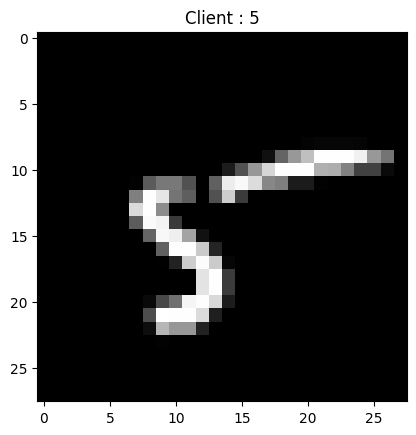

Poids du gate pour cette image :
tensor([0.3200, 0.0966, 0.1506, 0.4329])


In [6]:
img = donnees[0].cpu().view(28, 28)

plt.imshow(img, cmap="gray")
plt.title(f"Client : {labels[0].item()}")
plt.show()

print("Poids du gate pour cette image :")
print(poids[0].detach().cpu())


# Heatmap : spécialisation du gate

On calcule une matrice 10 × 4 :
- 10 chiffres
- 4 experts
- valeur = importance moyenne donnée par le gate


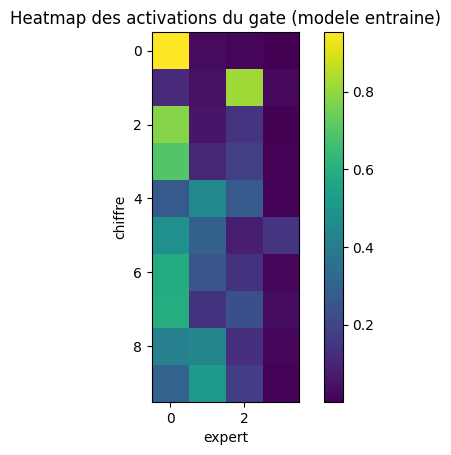

In [8]:
activ_moy = torch.zeros(10, 4)
compte = torch.zeros(10)

for d, l in loader:
    d = d.to(appareil)
    l = l.to(appareil)

    scores = moe.gate(d)
    poids = F.softmax(scores, dim=1)

    for i in range(10):
        mask = (l == i)
        if mask.sum() > 0:
            activ_moy[i] += poids[mask].mean(dim=0).detach().cpu()
            compte[i] += 1

    if compte.sum() > 200:
        break

activ_moy = activ_moy / compte.unsqueeze(1)

plt.imshow(activ_moy.numpy(), cmap="viridis")
plt.colorbar()
plt.xlabel("expert")
plt.ylabel("chiffre")
plt.title("Heatmap des activations du gate (modele entraine)")
plt.show()




On charge maintenant le modèle Dense pour comparer les performances.


In [9]:
dense = ModeleDense()
dense.load_state_dict(torch.load("modele_dense_mnist.pth", map_location=appareil))
dense.to(appareil)
dense.eval()

print("Dense chargé")


Dense chargé


C:\Users\paulh\AppData\Local\Temp\ipykernel_14052\3089664131.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dense.load_state_dict(torch.load("modele_dense_mnist.pth", m



On évalue les deux modèles sur le jeu de test.


In [10]:
test = datasets.MNIST(root="data_mnist", train=False, download=True, transform=transfo)
loaderTest = DataLoader(test, batch_size=256, shuffle=False)

def calculerAccuracy(modele):
    bons = 0
    total = 0
    with torch.no_grad():
        for d, l in loaderTest:
            d = d.to(appareil)
            l = l.to(appareil)
            o = modele(d)
            bons += (o.argmax(dim=1) == l).sum().item()
            total += l.size(0)
    return bons / total

acc_moe = calculerAccuracy(moe)
acc_dense = calculerAccuracy(dense)

print("accuracy MoE  :", acc_moe)
print("accuracy Dense:", acc_dense)


accuracy MoE  : 0.9762
accuracy Dense: 0.9805




On prend une image du test et on affiche la sortie brute de chaque expert,
avant la combinaison du gate.


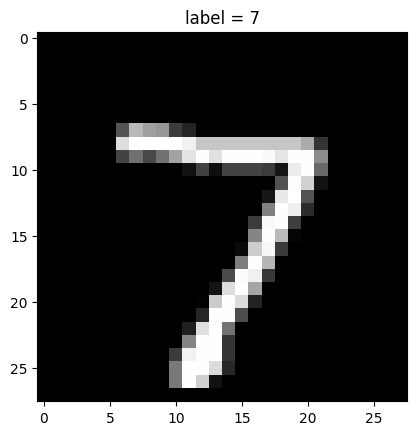

expert 0 -> prediction brute : tensor([[-6.5757,  0.7406, -0.3304, -3.9478, -3.4591, -6.6085, -9.9692,  9.9011,
         -3.0474, -3.8764]])
expert 1 -> prediction brute : tensor([[ -5.1879, -10.4868,   0.4366,   6.4471, -17.5694,  -7.7879, -28.2928,
           7.2090,  -2.7717,   0.2083]])
expert 2 -> prediction brute : tensor([[ -6.9681,  -4.6486,  -9.9878,  -2.6581,  -4.0193,  -8.1701, -12.4414,
          15.2555,  -8.2288,  -7.3388]])
expert 3 -> prediction brute : tensor([[-11.8098, -12.8667,  -2.1175,  -6.8204, -13.5874,  13.2478, -21.5113,
           8.8151,  -3.6325,   1.4903]])


In [11]:
d, l = next(iter(loaderTest))
x = d[0].to(appareil)

plt.imshow(x.cpu().view(28,28), cmap="gray")
plt.title(f"label = {l[0].item()}")
plt.show()

with torch.no_grad():
    logits = [expert(x.unsqueeze(0)) for expert in moe.listeExperts]

for i, log in enumerate(logits):
    print(f"expert {i} -> prediction brute :", log)
